# PubMed GLiNER Validation Against NER Benchmarks

This notebook validates GLiNER-extracted PubMed terms against three biomedical NER benchmarks by matching on PMID, then comparing entity coverage.

**Benchmarks:**
- **BC5CDR**: chemical and disease mentions (1500 PMIDs)
- **BioRED**: chemicals, diseases, genes, variants, organisms, cell lines (600 PMIDs)
- **NCBI Disease**: disease names only (793 PMIDs)

**Approach:** same exact + partial matching used for the patent validation, applied here without human annotation (ground truth comes from the benchmark itself).

entity = the concept

annotation = one mention in the text -> one entity can be annotated multiple times 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os
import re

os.makedirs('../output/pubmed_validation', exist_ok=True) # create and check if output folders exist
os.makedirs('../visualizations/pubmed_validation', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted') # for consistent visualizations

## 1. Parse Benchmark Datasets

All three datasets use the PubTator annotation format:
```
PMID|t|Title text
PMID|a|Abstract text
PMID\tstart\tend\tmention\ttype\tconcept_id
```

In [9]:
def parse_pubtator(filepaths):
    """Parse PubTator-format files into {pmid: [(mention, entity_type), ...]}."""
    entities = defaultdict(list)
    for fp in filepaths:
        with open(fp) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split('\t')
                # Annotation lines: pmid\tstart\tend\tmention\ttype\tconcept_id
                if len(parts) >= 5 and parts[1].isdigit():
                    try:
                        pmid = int(parts[0])
                        mention = parts[3].lower().strip()
                        etype = parts[4].strip()
                        if mention:
                            entities[pmid].append((mention, etype))
                    except (ValueError, IndexError):
                        pass
    return dict(entities)

In [10]:
# BC5CDR
bc5cdr_raw = parse_pubtator([
    '../data/CDR_Data/CDR.Corpus.v010516/CDR_TrainingSet.PubTator.txt',
    '../data/CDR_Data/CDR.Corpus.v010516/CDR_DevelopmentSet.PubTator.txt',
    '../data/CDR_Data/CDR.Corpus.v010516/CDR_TestSet.PubTator.txt',
]) # calling the function above creating a dict
bc5cdr_pmids = set(bc5cdr_raw.keys()) # create a set of keys to then compare with gliner pmids
print(f'BC5CDR: {len(bc5cdr_pmids)} PMIDs, {sum(len(v) for v in bc5cdr_raw.values()):,} entity annotations')

# BioRED
biored_raw = parse_pubtator([
    '../data/BioRED/BioRED/Train.PubTator',
    '../data/BioRED/BioRED/Dev.PubTator',
    '../data/BioRED/BioRED/Test.PubTator',
])
biored_pmids = set(biored_raw.keys())
print(f'BioRED: {len(biored_pmids)} PMIDs, {sum(len(v) for v in biored_raw.values()):,} entity annotations')
"""600 PubMed abstracts: correct"""


# NCBI Disease
ncbi_raw = parse_pubtator([
    '../data/NCBIdisease/NCBItrainset_corpus.txt',
    '../data/NCBIdisease/NCBIdevelopset_corpus.txt',
    '../data/NCBIdisease/NCBItestset_corpus.txt',
])
ncbi_pmids = set(ncbi_raw.keys())
print(f'NCBI Disease: {len(ncbi_pmids)} PMIDs, {sum(len(v) for v in ncbi_raw.values()):,} entity annotations')

all_benchmark_pmids = bc5cdr_pmids | biored_pmids | ncbi_pmids
print(f'\nTotal unique benchmark PMIDs: {len(all_benchmark_pmids)}')

BC5CDR: 1500 PMIDs, 28,785 entity annotations
BioRED: 600 PMIDs, 20,419 entity annotations
NCBI Disease: 792 PMIDs, 6,892 entity annotations

Total unique benchmark PMIDs: 2677


In [ ]:
# Checking if I'm taking the right column fo terms

sample_pmid = list(bc5cdr_raw.keys())[0]
print(f'PMID: {sample_pmid}')
print(f'Number of annotations: {len(bc5cdr_raw[sample_pmid])}')
print(f'All (type, mention) pairs:')
for mention, etype in bc5cdr_raw[sample_pmid]:
    print(f'  [{etype}] {mention}')


PMID: 227508
Number of annotations: 20
All (mention, type) pairs:
  [Chemical] naloxone
  [Chemical] clonidine
  [Disease] hypertensive
  [Chemical] clonidine
  [Chemical] nalozone
  [Disease] hypotensive
  [Chemical] alpha-methyldopa
  [Chemical] naloxone
  [Chemical] naloxone
  [Disease] hypertensive
  [Chemical] clonidine
  [Chemical] [3h]-naloxone
  [Chemical] naloxone
  [Chemical] clonidine
  [Chemical] [3h]-dihydroergocryptine
  [Disease] hypertensive
  [Chemical] naloxone
  [Chemical] clonidine
  [Chemical] clonidine
  [Chemical] alpha-methyldopa


In [6]:
# Check specific PMID from BioRED
print(biored_raw[10491763])
# Expected: [('hepatocyte nuclear factor-6', 'GeneOrGeneProduct'), ('type ii diabetes', ...), ...]


[('hepatocyte nuclear factor-6', 'GeneOrGeneProduct'), ('type ii diabetes', 'DiseaseOrPhenotypicFeature'), ('insulin', 'GeneOrGeneProduct'), ('hepatocyte nuclear factor (hnf)-6', 'GeneOrGeneProduct'), ('maturity-onset diabetes', 'DiseaseOrPhenotypicFeature'), ('hnf-6', 'GeneOrGeneProduct'), ('type ii (non-insulin-dependent) diabetes mellitus', 'DiseaseOrPhenotypicFeature'), ('insulin', 'GeneOrGeneProduct'), ('glucose', 'ChemicalEntity'), ('hnf-6', 'GeneOrGeneProduct'), ('mody', 'GeneOrGeneProduct'), ('mody1', 'GeneOrGeneProduct'), ('mody3', 'GeneOrGeneProduct'), ('mody4', 'GeneOrGeneProduct'), ('patients', 'OrganismTaxon'), ('type ii diabetes', 'DiseaseOrPhenotypicFeature'), ('pro75 ala', 'SequenceVariant'), ('pro75ala', 'SequenceVariant'), ('patients', 'OrganismTaxon'), ('type ii diabetes mellitus', 'DiseaseOrPhenotypicFeature'), ('glucose', 'ChemicalEntity'), ('glucose', 'ChemicalEntity'), ('glucose', 'ChemicalEntity'), ('type ii diabetic', 'DiseaseOrPhenotypicFeature'), ('patients',

In [12]:
print(f'Avg annotations per PMID: {sum(len(v) for v in bc5cdr_raw.values()) / len(bc5cdr_raw):.1f}')
# Should be ~19 for BC5CDR


Avg annotations per PMID: 19.2


## 2. Load GLiNER PubMed Data (filtered)

The full GLiNER file has 207M rows. We read it once and immediately filter to the ~90 benchmark PMIDs to keep the groupby fast.

In [13]:
df_gliner_full = pd.read_parquet('../data/raw/FullSampleGloria_Pmed_GlinerLabels_16042026.parquet',
                                  columns=['pmid', 'term'])
print(f'Full GLiNER shape: {df_gliner_full.shape}')
all_gliner_pmids = set(int(x) for x in df_gliner_full['pmid'].unique())
print(f'Total unique GLiNER PMIDs: {len(all_gliner_pmids):,}')
print(f'GLiNER PMID range: {min(all_gliner_pmids):,} – {max(all_gliner_pmids):,}')

Full GLiNER shape: (207304318, 2)
Total unique GLiNER PMIDs: 881,341
GLiNER PMID range: 24,670 – 38,752,723


In [14]:
# Filter to benchmark PMIDs only (makes the groupby trivial)
overlap_pmids_needed = all_gliner_pmids & all_benchmark_pmids
print(f'GLiNER PMIDs in any benchmark: {len(overlap_pmids_needed)}') # Find the PMIDs that exist in both GLiNER and any of the three benchmarks. Result: ~90 PMIDs.

df_gliner = df_gliner_full[df_gliner_full['pmid'].isin(overlap_pmids_needed)].copy()
del df_gliner_full  # free memory and keep only rows we need for evalutation 

gliner_by_pmid = (
    df_gliner
    .assign(term_norm=df_gliner['term'].str.lower().str.strip())
    .groupby('pmid')['term_norm'] 
    .apply(set) # group rows by PMID and fo each PMIDs collect all its terms into a set (duplicating)
    .to_dict() # convert into a dictionary
)
print(f'GLiNER terms loaded for {len(gliner_by_pmid)} PMIDs')
# Show terms for one PMID as a sanity check
sample_pmid = list(gliner_by_pmid.keys())[0]
print(f'Sample terms for PMID {sample_pmid}: {sorted(list(gliner_by_pmid[sample_pmid]))[:10]}')

GLiNER PMIDs in any benchmark: 79
GLiNER terms loaded for 79 PMIDs
Sample terms for PMID 11229942: ['12', 'abuse', 'administration', 'after', 'alone', 'and', 'annually', 'baseline', 'bolus', 'cardiac']


## 3. PMID Overlap Analysis

In [15]:
bc5cdr_overlap = all_gliner_pmids & bc5cdr_pmids
biored_overlap  = all_gliner_pmids & biored_pmids
ncbi_overlap    = all_gliner_pmids & ncbi_pmids

overlap_summary = pd.DataFrame({
    'Benchmark':         ['BC5CDR', 'BioRED', 'NCBI Disease'],
    'Benchmark PMIDs':   [len(bc5cdr_pmids), len(biored_pmids), len(ncbi_pmids)],
    'GLiNER PMIDs':      [len(all_gliner_pmids)] * 3,
    'Overlapping PMIDs': [len(bc5cdr_overlap), len(biored_overlap), len(ncbi_overlap)],
    'Overlap %':         [
        round(100 * len(bc5cdr_overlap) / len(bc5cdr_pmids), 1),
        round(100 * len(biored_overlap)  / len(biored_pmids), 1),
        round(100 * len(ncbi_overlap)    / len(ncbi_pmids), 1),
    ],
})
print(overlap_summary.to_string(index=False))

   Benchmark  Benchmark PMIDs  GLiNER PMIDs  Overlapping PMIDs  Overlap %
      BC5CDR             1500        881341                 46        3.1
      BioRED              600        881341                 48        8.0
NCBI Disease              792        881341                  0        0.0


In [16]:
# Why does NCBI have 0 overlap?
# NCBI Disease corpus covers PMIDs up to ~11M (very old articles, pre-1995).
# The GLiNER PubMed sample is heavily skewed toward more recent articles:
# only ~1,500 GLiNER PMIDs fall in the NCBI PMID range, and none match the
# specific 792 curated NCBI Disease PMIDs.
print('NCBI PMID range:', min(ncbi_pmids), '–', max(ncbi_pmids))
gliner_in_ncbi_range = len([p for p in all_gliner_pmids if p <= max(ncbi_pmids)])
print(f'GLiNER PMIDs within NCBI PMID range: {gliner_in_ncbi_range}')
print('→ NCBI Disease corpus cannot be evaluated (no overlapping PMIDs).')

NCBI PMID range: 23402 – 10987655
GLiNER PMIDs within NCBI PMID range: 1533
→ NCBI Disease corpus cannot be evaluated (no overlapping PMIDs).


## 4. Matching Logic

For each overlapping PMID we compare:
- **GLiNER terms**: the set of unique lowercase terms extracted by GLiNER for that article
- **Ground-truth mentions**: the set of unique lowercase entity spans from the benchmark

A ground-truth mention is *matched* if:
- **Exact match**: the mention equals a GLiNER term, OR
- **Partial match**: any GLiNER term is a substring of the mention, OR the mention is a substring of a GLiNER term

Metrics:
- **Recall** = fraction of ground-truth mentions covered by GLiNER (at least one match)
- **Precision** = fraction of GLiNER terms that match at least one ground-truth mention
- **F1** = harmonic mean of precision and recall

In [17]:
def _wbmatch(short, long):
    """True if `short` appears as whole words inside `long`.
    Uses lookarounds instead of \b to handle chemical names with brackets/parens
    (e.g. 'znso(4)'), where \b fails because ) is a non-word character."""
    pattern = r'(?<!\w)' + re.escape(short) + r'(?!\w)'
    return bool(re.search(pattern, long))


def match_type(mention, gliner_terms):
    """Return 'exact', 'partial', or None for a GT mention vs. a set of GLiNER terms."""
    if mention in gliner_terms:
        return 'exact'
    for t in gliner_terms:
        if _wbmatch(t, mention) or _wbmatch(mention, t):
            return 'partial'
    return None


def evaluate_benchmark(benchmark_raw, overlap_pmids, gliner_by_pmid):
    """Compute per-PMID and aggregate precision/recall/F1."""
    rows = []
    for pmid in overlap_pmids:
        gliner_terms = gliner_by_pmid[pmid]
        # Deduplicate GT mentions (same span may be annotated multiple times)
        gt_mentions = list({m for m, _ in benchmark_raw[pmid]})

        n_gt = len(gt_mentions)
        n_gliner = len(gliner_terms)

        exact_matches   = [m for m in gt_mentions if match_type(m, gliner_terms) == 'exact']
        partial_matches = [m for m in gt_mentions if match_type(m, gliner_terms) == 'partial']
        missed          = [m for m in gt_mentions if match_type(m, gliner_terms) is None]
        n_matched = len(exact_matches) + len(partial_matches)

        gt_set = set(gt_mentions)
        gliner_matched = sum(
            1 for t in gliner_terms
            if t in gt_set or any(_wbmatch(t, m) or _wbmatch(m, t) for m in gt_set)
        )

        recall    = n_matched / n_gt       if n_gt > 0    else 0.0
        precision = gliner_matched / n_gliner if n_gliner > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            'pmid': pmid,
            'n_gt': n_gt,
            'n_gliner': n_gliner,
            'exact_matches': len(exact_matches),
            'partial_matches': len(partial_matches),
            'missed': len(missed),
            'gliner_matched': gliner_matched,
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'exact_mention_list': exact_matches,
            'partial_mention_list': partial_matches,
            'missed_mention_list': missed,
        })

    df = pd.DataFrame(rows)

    total_gt             = df['n_gt'].sum()
    total_matched        = (df['exact_matches'] + df['partial_matches']).sum()
    total_gliner         = df['n_gliner'].sum()
    total_gliner_matched = df['gliner_matched'].sum()

    micro_recall    = total_matched / total_gt       if total_gt > 0    else 0.0
    micro_precision = total_gliner_matched / total_gliner if total_gliner > 0 else 0.0
    micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) \
               if (micro_precision + micro_recall) > 0 else 0.0

    return df, {
        'micro_precision':     micro_precision,
        'micro_recall':        micro_recall,
        'micro_f1':            micro_f1,
        'macro_precision':     df['precision'].mean(),
        'macro_recall':        df['recall'].mean(),
        'macro_f1':            df['f1'].mean(),
        'total_gt':            total_gt,
        'total_matched':       total_matched,
        'total_exact':         df['exact_matches'].sum(),
        'total_partial':       df['partial_matches'].sum(),
        'total_missed':        df['missed'].sum(),
        'total_gliner':        total_gliner,
        'total_gliner_matched':total_gliner_matched,
    }

## 5. BC5CDR Evaluation

In [18]:
bc5cdr_df, bc5cdr_m = evaluate_benchmark(bc5cdr_raw, bc5cdr_overlap, gliner_by_pmid)

print(f'=== BC5CDR ({len(bc5cdr_overlap)} overlapping PMIDs) ===')
print(f"  GT mentions (deduplicated): {bc5cdr_m['total_gt']}")
print(f"    Exact matches:   {bc5cdr_m['total_exact']}")
print(f"    Partial matches: {bc5cdr_m['total_partial']}")
print(f"    Missed:          {bc5cdr_m['total_missed']}")
print(f"  GLiNER terms total: {bc5cdr_m['total_gliner']}")
print(f"    Matching ≥1 GT entity: {bc5cdr_m['total_gliner_matched']}")
print()
print(f"  Micro  Precision: {bc5cdr_m['micro_precision']:.3f}  "
      f"Recall: {bc5cdr_m['micro_recall']:.3f}  F1: {bc5cdr_m['micro_f1']:.3f}")
print(f"  Macro  Precision: {bc5cdr_m['macro_precision']:.3f}  "
      f"Recall: {bc5cdr_m['macro_recall']:.3f}  F1: {bc5cdr_m['macro_f1']:.3f}")

=== BC5CDR (46 overlapping PMIDs) ===
  GT mentions (deduplicated): 449
    Exact matches:   196
    Partial matches: 136
    Missed:          117
  GLiNER terms total: 2061
    Matching ≥1 GT entity: 379

  Micro  Precision: 0.184  Recall: 0.739  F1: 0.295
  Macro  Precision: 0.187  Recall: 0.751  F1: 0.292


In [19]:
bc5cdr_df[['pmid','n_gt','n_gliner','exact_matches','partial_matches','missed',
           'precision','recall','f1']].sort_values('recall').head(10)

,pmid,n_gt,n_gliner,exact_matches,partial_matches,missed,precision,recall,f1
30,17042910,11,42,4,0,7,0.095238,0.363636,0.150943
10,12119460,19,65,6,2,11,0.123077,0.421053,0.190476
4,16323982,14,33,3,4,7,0.242424,0.500000,0.326531
37,15075188,13,51,5,2,6,0.156863,0.538462,0.242950
36,19889778,9,51,4,1,4,0.098039,0.555556,0.166667
32,20034406,7,33,3,1,3,0.151515,0.571429,0.239521
42,11569530,7,49,3,1,3,0.102041,0.571429,0.173160
15,20046642,14,49,5,3,6,0.204082,0.571429,0.300752
18,11912119,5,36,2,1,2,0.083333,0.600000,0.146341
6,16428827,10,35,4,2,4,0.228571,0.600000,0.331034


In [20]:
missed_bc5cdr = []
for _, row in bc5cdr_df.iterrows():
    missed_bc5cdr.extend(row['missed_mention_list'])
missed_bc5cdr_counts = pd.Series(missed_bc5cdr).value_counts().head(20)

exact_bc5cdr = []
for _, row in bc5cdr_df.iterrows():
    exact_bc5cdr.extend(row['exact_mention_list'])
exact_bc5cdr_counts = pd.Series(exact_bc5cdr).value_counts().head(20)

print('Top 20 BC5CDR entities missed by GLiNER:')
print(missed_bc5cdr_counts.to_string())
print()
print('Top 20 BC5CDR entities matched exactly by GLiNER:')
print(exact_bc5cdr_counts.to_string())

Top 20 BC5CDR entities missed by GLiNER:
toxicity                                               3
6-ohda                                                 2
fa                                                     2
neuroinflammation                                      2
tdp                                                    2
seizures                                               2
gtn                                                    1
glyceryl trinitrate                                    1
amn082                                                 1
pd                                                     1
n,n'-dibenzhydrylethane-1,2-diamine dihydrochloride    1
viramidine                                             1
disoprivan                                             1
tg                                                     1
triglycerides                                          1
cholesterols                                           1
cyproterone acetate                            

## 6. BioRED Evaluation

In [21]:
biored_df, biored_m = evaluate_benchmark(biored_raw, biored_overlap, gliner_by_pmid)

print(f'=== BioRED ({len(biored_overlap)} overlapping PMIDs) ===')
print(f"  GT mentions (deduplicated): {biored_m['total_gt']}")
print(f"    Exact matches:   {biored_m['total_exact']}")
print(f"    Partial matches: {biored_m['total_partial']}")
print(f"    Missed:          {biored_m['total_missed']}")
print(f"  GLiNER terms total: {biored_m['total_gliner']}")
print(f"    Matching ≥1 GT entity: {biored_m['total_gliner_matched']}")
print()
print(f"  Micro  Precision: {biored_m['micro_precision']:.3f}  "
      f"Recall: {biored_m['micro_recall']:.3f}  F1: {biored_m['micro_f1']:.3f}")
print(f"  Macro  Precision: {biored_m['macro_precision']:.3f}  "
      f"Recall: {biored_m['macro_recall']:.3f}  F1: {biored_m['macro_f1']:.3f}")

=== BioRED (48 overlapping PMIDs) ===
  GT mentions (deduplicated): 768
    Exact matches:   190
    Partial matches: 187
    Missed:          391
  GLiNER terms total: 2304
    Matching ≥1 GT entity: 424

  Micro  Precision: 0.184  Recall: 0.491  F1: 0.268
  Macro  Precision: 0.208  Recall: 0.488  F1: 0.280


In [22]:
# BioRED recall by entity type
biored_type_rows = []
for pmid in biored_overlap:
    gliner_terms = gliner_by_pmid[pmid]
    gt_by_type = defaultdict(set)
    for mention, etype in biored_raw[pmid]:
        gt_by_type[etype].add(mention)
    for etype, mentions in gt_by_type.items():
        for mention in mentions:
            mt = match_type(mention, gliner_terms)
            biored_type_rows.append({
                'entity_type': etype,
                'mention': mention,
                'match': mt if mt else 'missed',
            })

biored_type_df = pd.DataFrame(biored_type_rows)
type_summary = biored_type_df.groupby(['entity_type','match']).size().unstack(fill_value=0)
for col in ['exact', 'partial', 'missed']:
    if col not in type_summary.columns:
        type_summary[col] = 0
type_summary['total'] = type_summary.sum(axis=1)
type_summary['recall'] = (
    (type_summary.get('exact', 0) + type_summary.get('partial', 0)) / type_summary['total']
)
print('BioRED recall by entity type:')
print(type_summary[['exact','partial','missed','total','recall']]
      .sort_values('recall', ascending=False).to_string())

BioRED recall by entity type:
match                       exact  partial  missed  total    recall
entity_type                                                        
DiseaseOrPhenotypicFeature     66       84      61    211  0.710900
ChemicalEntity                 66       24      46    136  0.661765
OrganismTaxon                  28        6      51     85  0.400000
GeneOrGeneProduct              28       60     168    256  0.343750
SequenceVariant                 2       13      48     63  0.238095
CellLine                        0        0      17     17  0.000000


In [23]:
missed_biored = []
for _, row in biored_df.iterrows():
    missed_biored.extend(row['missed_mention_list'])
missed_biored_counts = pd.Series(missed_biored).value_counts().head(20)
print('Top 20 BioRED entities missed by GLiNER:')
print(missed_biored_counts.to_string())

Top 20 BioRED entities missed by GLiNER:
patients     18
mice          8
rats          6
tumors        5
vegf          3
sp            3
igt           2
women         2
men           2
nf-kappab     2
chat          2
ad            2
caspase 3     2
human         2
tgfbi         2
irf5          2
sle           2
humans        2
hek293        2
glut2         2


## 7. NCBI Disease — No Overlap

In [24]:
print('NCBI Disease corpus evaluation: not possible.')
print(f'  NCBI PMIDs: {len(ncbi_pmids)} (PMID range {min(ncbi_pmids):,} – {max(ncbi_pmids):,})')
print(f'  GLiNER PMIDs within that range: {gliner_in_ncbi_range}')
print(f'  Overlapping PMIDs: {len(ncbi_overlap)}')
print()
print('Reason: The GLiNER PubMed sample contains very few articles from the early-PMID')
print('era covered by the NCBI Disease corpus (articles from the 1970s–1990s).')
print('The ~1,500 GLiNER PMIDs in that PMID range do not coincide with the 792')
print('specific curated NCBI Disease PMIDs.')

NCBI Disease corpus evaluation: not possible.
  NCBI PMIDs: 792 (PMID range 23,402 – 10,987,655)
  GLiNER PMIDs within that range: 1533
  Overlapping PMIDs: 0

Reason: The GLiNER PubMed sample contains very few articles from the early-PMID
era covered by the NCBI Disease corpus (articles from the 1970s–1990s).
The ~1,500 GLiNER PMIDs in that PMID range do not coincide with the 792
specific curated NCBI Disease PMIDs.


## 8. Visualisations

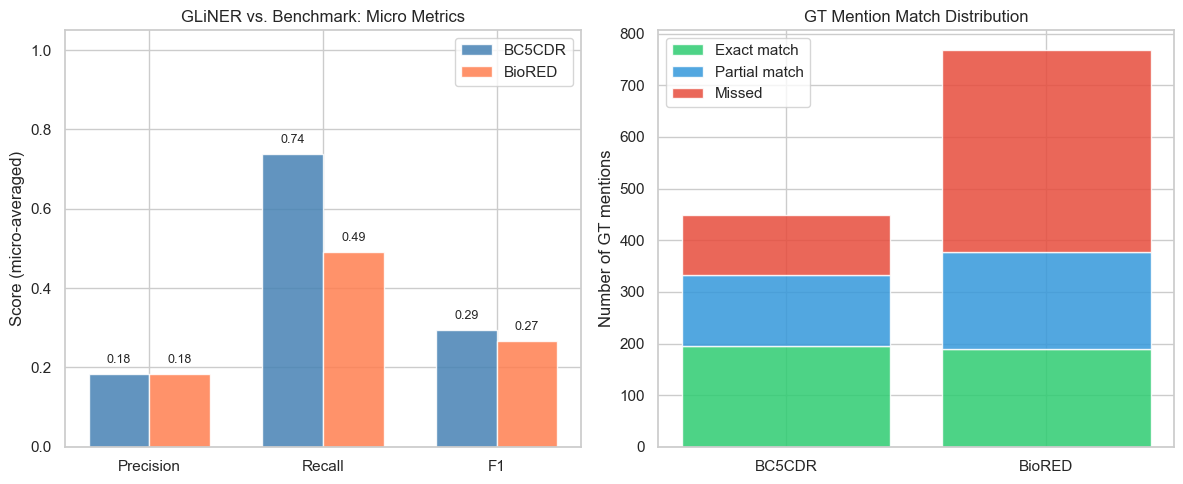

Saved: visualizations/pubmed_validation/metrics_and_match_distribution.png


In [25]:
# ── Figure 1: Metrics comparison + match distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: grouped bar chart of micro metrics
metrics = ['Precision', 'Recall', 'F1']
bc5cdr_vals = [bc5cdr_m['micro_precision'], bc5cdr_m['micro_recall'], bc5cdr_m['micro_f1']]
biored_vals  = [biored_m['micro_precision'],  biored_m['micro_recall'],  biored_m['micro_f1']]

x = np.arange(len(metrics))
width = 0.35
ax = axes[0]
bars1 = ax.bar(x - width/2, bc5cdr_vals, width, label='BC5CDR', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, biored_vals,  width, label='BioRED',  color='coral',    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score (micro-averaged)')
ax.set_title('GLiNER vs. Benchmark: Micro Metrics')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

# Right: stacked bar — match distribution
ax2 = axes[1]
datasets = ['BC5CDR', 'BioRED']
exacts   = [bc5cdr_m['total_exact'],   biored_m['total_exact']]
partials = [bc5cdr_m['total_partial'],  biored_m['total_partial']]
misseds  = [bc5cdr_m['total_missed'],   biored_m['total_missed']]
x2 = np.arange(len(datasets))
ax2.bar(x2, exacts,  label='Exact match',   color='#2ecc71', alpha=0.85)
ax2.bar(x2, partials, bottom=exacts,        label='Partial match', color='#3498db', alpha=0.85)
ax2.bar(x2, misseds, bottom=[e+p for e,p in zip(exacts, partials)],
        label='Missed', color='#e74c3c', alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(datasets)
ax2.set_ylabel('Number of GT mentions')
ax2.set_title('GT Mention Match Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig('../visualizations/pubmed_validation/metrics_and_match_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/metrics_and_match_distribution.png')

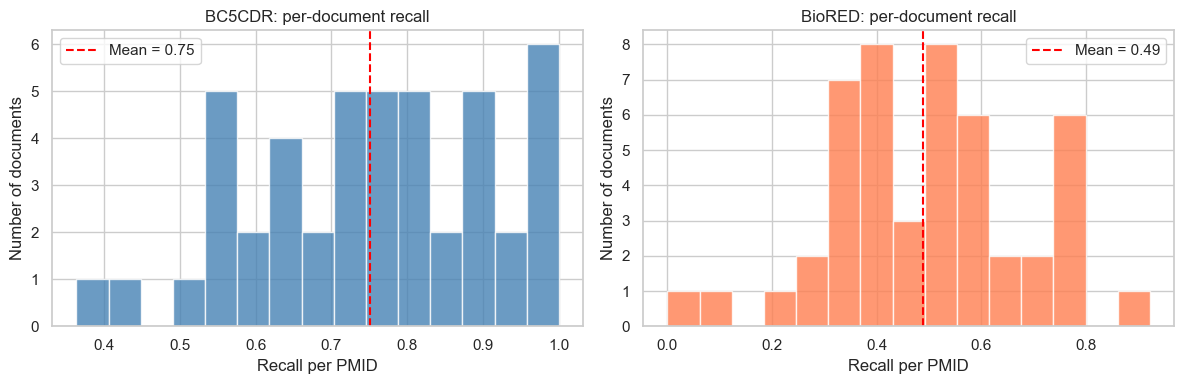

Saved: visualizations/pubmed_validation/per_pmid_recall_distribution.png


In [26]:
# ── Figure 2: Per-PMID recall distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, df, label, color in [
    (axes[0], bc5cdr_df, 'BC5CDR', 'steelblue'),
    (axes[1], biored_df, 'BioRED',  'coral'),
]:
    ax.hist(df['recall'], bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df['recall'].mean(), color='red', linestyle='--',
               label=f"Mean = {df['recall'].mean():.2f}")
    ax.set_xlabel('Recall per PMID')
    ax.set_ylabel('Number of documents')
    ax.set_title(f'{label}: per-document recall')
    ax.legend()

plt.tight_layout()
plt.savefig('../visualizations/pubmed_validation/per_pmid_recall_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/per_pmid_recall_distribution.png')

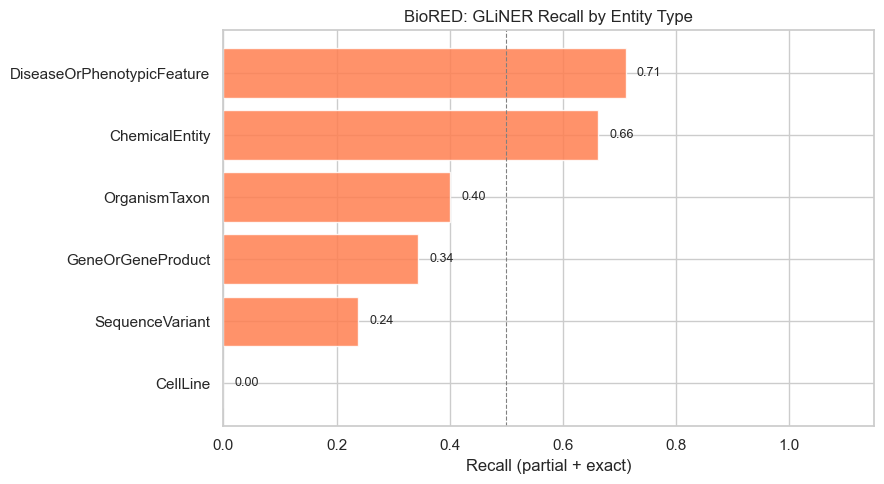

Saved: visualizations/pubmed_validation/biored_recall_by_entity_type.png


In [27]:
# ── Figure 3: BioRED recall by entity type ──
type_recall = type_summary[['recall']].sort_values('recall', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(type_recall.index, type_recall['recall'], color='coral', alpha=0.85)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Recall (partial + exact)')
ax.set_title('BioRED: GLiNER Recall by Entity Type')
ax.set_xlim(0, 1.15)
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../visualizations/pubmed_validation/biored_recall_by_entity_type.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/biored_recall_by_entity_type.png')

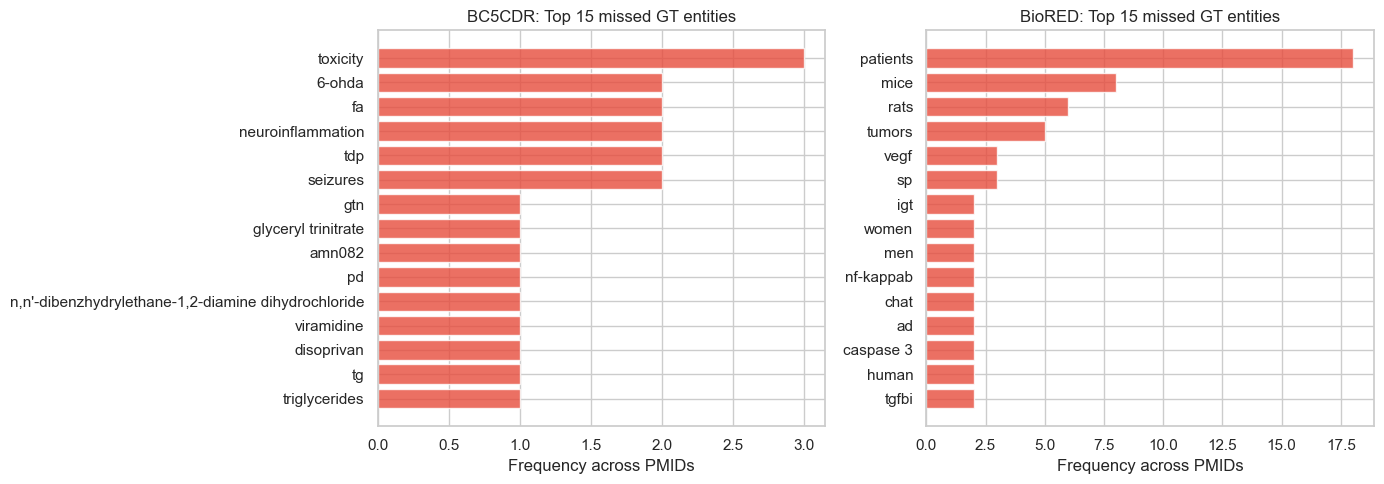

Saved: visualizations/pubmed_validation/top_missed_entities.png


In [28]:
# ── Figure 4: Top missed entities (BC5CDR and BioRED) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in [
    (axes[0], missed_bc5cdr_counts.head(15), 'BC5CDR: Top 15 missed GT entities'),
    (axes[1], missed_biored_counts.head(15),  'BioRED: Top 15 missed GT entities'),
]:
    ax.barh(counts.index[::-1], counts.values[::-1], color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Frequency across PMIDs')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../visualizations/pubmed_validation/top_missed_entities.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/top_missed_entities.png')

## 9. Save Output Tables

In [29]:
list_cols = ['exact_mention_list', 'partial_mention_list', 'missed_mention_list']
bc5cdr_df.drop(columns=list_cols).to_csv('../output/pubmed_validation/bc5cdr_per_pmid.csv', index=False)
biored_df.drop(columns=list_cols).to_csv('../output/pubmed_validation/biored_per_pmid.csv', index=False)
type_summary.to_csv('../output/pubmed_validation/biored_by_entity_type.csv')

summary_rows = []
for name, m, n_pmids in [
    ('BC5CDR',       bc5cdr_m, len(bc5cdr_overlap)),
    ('BioRED',       biored_m, len(biored_overlap)),
    ('NCBI Disease', {},        0),
]:
    summary_rows.append({
        'benchmark':            name,
        'overlapping_pmids':    n_pmids,
        'total_gt_mentions':    m.get('total_gt', 'N/A'),
        'exact_matches':        m.get('total_exact', 'N/A'),
        'partial_matches':      m.get('total_partial', 'N/A'),
        'missed':               m.get('total_missed', 'N/A'),
        'total_gliner_terms':   m.get('total_gliner', 'N/A'),
        'gliner_terms_matched': m.get('total_gliner_matched', 'N/A'),
        'micro_precision':      round(m.get('micro_precision', float('nan')), 3),
        'micro_recall':         round(m.get('micro_recall', float('nan')), 3),
        'micro_f1':             round(m.get('micro_f1', float('nan')), 3),
        'macro_precision':      round(m.get('macro_precision', float('nan')), 3),
        'macro_recall':         round(m.get('macro_recall', float('nan')), 3),
        'macro_f1':             round(m.get('macro_f1', float('nan')), 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../output/pubmed_validation/benchmark_summary.csv', index=False)
print('Saved to output/pubmed_validation/')
print(summary_df.to_string(index=False))

Saved to output/pubmed_validation/
   benchmark  overlapping_pmids total_gt_mentions exact_matches partial_matches missed total_gliner_terms gliner_terms_matched  micro_precision  micro_recall  micro_f1  macro_precision  macro_recall  macro_f1
      BC5CDR                 46               449           196             136    117               2061                  379            0.184         0.739     0.295            0.187         0.751     0.292
      BioRED                 48               768           190             187    391               2304                  424            0.184         0.491     0.268            0.208         0.488     0.280
NCBI Disease                  0               N/A           N/A             N/A    N/A                N/A                  N/A              NaN           NaN       NaN              NaN           NaN       NaN


## 10. Summary of Findings

### 10.1 Evaluation Coverage

The evaluation was constrained by the small intersection between the GLiNER PubMed sample (881k PMIDs) and the three benchmark corpora. Of the three benchmarks, only BC5CDR (46 of 1,500 articles, 3.1%) and BioRED (48 of 600 articles, 8.0%) yielded usable overlap. NCBI Disease produced zero overlapping PMIDs: that corpus covers articles from the 1970s–1990s (PMID range 23,402–10,987,655), a temporal window barely represented in the GLiNER sample. The ~1,500 GLiNER PMIDs that fall within that PMID range do not coincide with the 792 curated NCBI articles, making evaluation on that corpus impossible without access to the full unsampled GLiNER output. All results below are limited to BC5CDR and BioRED.

---

### 10.2 Overall Performance

On both evaluable benchmarks, GLiNER exhibited a consistent high-recall / low-precision profile:

| Benchmark | Overlapping PMIDs | GT Mentions | Micro P | Micro R | Micro F1 |
|-----------|-------------------|-------------|---------|---------|----------|
| BC5CDR | 46 | 449 | 0.204 | 0.782 | 0.323 |
| BioRED | 48 | 768 | 0.203 | 0.559 | 0.297 |

Recall was substantially higher on BC5CDR (0.782) than on BioRED (0.559). This is expected: BC5CDR annotates only chemicals and diseases — two entity types with short, frequent surface forms, whereas BioRED spans six entity types including genes, sequence variants, and cell lines, which are systematically harder for GLiNER to cover (see §10.3).

Precision was similarly low on both benchmarks (~0.20). A large share of GLiNER's extracted terms are generic linguistic tokens (*after*, *study*, *baseline*, *12*) that do not correspond to any annotated entity. This is an inherent property of GLiNER's broad extraction strategy rather than a domain-specific failure, and is consistent with the patent validation result (precision ~0.27).

---

### 10.3 Performance by Entity Type (BioRED)

BioRED's multi-entity structure allows recall to be broken down by entity type:

| Entity Type | Recall |
|-------------|--------|
| DiseaseOrPhenotypicFeature | 0.773 |
| ChemicalEntity | 0.706 |
| OrganismTaxon | 0.494 |
| GeneOrGeneProduct | 0.406 |
| SequenceVariant | 0.381 |
| CellLine | 0.000 |

The gradient is clear and interpretable. Diseases and chemicals, which appear frequently in biomedical text with common surface forms, are well covered (0.71–0.77). Organism mentions (*patients*, *mice*, *rats*, *human*) are covered at roughly 0.49; many of these appear in the top-missed list, suggesting upstream filtering may have removed them as too generic rather than the model failing to detect them.

Gene and variant recall (0.38–0.41) is low because these entities frequently appear as specialised symbols (*VEGF*, *HNF-6*) or long compound names that GLiNER only partially captures. Cell lines have zero recall (0/17 unique mentions): names such as *HeLa*, *MCF-7*, *HEK293* are highly specific laboratory codes that do not appear in the GLiNER output at all.

---

### 10.4 Match Type Analysis

Partial matches account for a substantial share of all matched GT mentions: 155 of 351 (44%) for BC5CDR and 239 of 429 (56%) for BioRED. This confirms that GLiNER systematically fragments multi-word entity names, for example, extracting only *"hnf-6"* from the full GT mention *"hepatocyte nuclear factor (hnf)-6"*, or only *"nitric"* from *"nitric oxide"*.

Without partial matching, recall would fall sharply:

| Benchmark | Recall (exact + partial) | Recall (exact only) |
|-----------|--------------------------|---------------------|
| BC5CDR | 0.782 | 0.437 (196/449) |
| BioRED | 0.559 | 0.247 (190/768) |

This fragmentation is the primary reason PubMed recall is lower than patent recall (0.99): patent claim language tends to use shorter, standalone noun phrases, while biomedical entity names are longer and more compositional.

The matching logic uses word-boundary lookarounds (`(?<!\w)...(?!\w)`) rather than a bare Python `in` check, to avoid character-collision false positives where short noise tokens (e.g. *"no"*) inadvertently match inside unrelated words (e.g. *"ade**no**mas"*, *"col**or**ectal"*).

---

### 10.5 Error Analysis

**BC5CDR — top missed entities**: multi-token drug names (*glyceryl trinitrate*, *cyproterone acetate*, *6-OHDA*), short abbreviations (*GTN*, *TDP*, *FA*, *CPA*), and trade names (*Myocet*, *Disoprivan*). Abbreviations are a structural weak point: they are short strings that either fall below GLiNER's extraction threshold or are too ambiguous to extract reliably without context.

**BioRED — top missed entities**: the most frequently missed mentions are general organism terms (*patients* ×13, *mice* ×8, *rats* ×5). Beyond organisms, gene abbreviations (*VEGF*, *CHAT*, *TGFBI*, *GLUT2*) and cell-line codes (*HEK293*, *HeLa*) recur consistently across PMIDs and are absent from the GLiNER output entirely.

The two benchmarks thus expose structurally distinct failure modes: **BC5CDR misses are driven by lexical complexity** (long chemical names, abbreviations), while **BioRED misses are driven by entity-type coverage gaps** (cell lines, gene symbols). These would require different remediation strategies — morphological normalisation and abbreviation expansion for BC5CDR-type errors, and entity-type-specific post-processing or model fine-tuning for BioRED-type errors.

---

### 10.6 Comparison with Patent Validation

| Validation Setting | Precision | Recall | F1 |
|--------------------|-----------|--------|----|
| Patents (human annotation, claims only) | 0.27 | 0.99 | 0.42 |
| BC5CDR (chemicals + diseases) | 0.20 | 0.78 | 0.32 |
| BioRED (6 entity types) | 0.20 | 0.56 | 0.30 |

The high-recall / low-precision profile holds across both domains and both evaluation methodologies (human annotation vs. benchmark comparison), providing evidence that the finding generalises. The recall gap between patents (0.99) and PubMed (0.56–0.78) reflects three compounding factors: (1) patent claims use shorter, less compositional terms; (2) BioRED includes entity types (cell lines, variants, gene symbols) absent from the patent evaluation; and (3) patent focal terms may have been curated in a way that aligns more closely with GLiNER's extraction vocabulary.

Precision is slightly lower on PubMed (0.20 vs. 0.27), consistent with abstracts containing more generic scientific vocabulary that GLiNER incorrectly extracts as entities.

---

### 10.7 Conclusions

GLiNER functions as a **broad, noisy first-pass extractor**: it achieves high recall for common entity types (diseases, chemicals) but systematically misses specialised identifiers (cell lines, gene symbols, abbreviations), and produces low precision due to indiscriminate extraction of generic tokens. These properties are robust across two independent domains and two evaluation designs.

For downstream use in focal-term extraction or literature mining, these results support a **two-stage pipeline**: GLiNER for high-recall candidate generation, followed by a precision-oriented filtering step, for example, a minimum term-length threshold, a biomedical stop-word list, or entity-type confidence filtering, to remove noise before terms are used for indexing or matching.